# Word2Vec (Implementación de Embeddings)

El objetivo de los *embeddings* es transformar palabras en vectores numéricos que capturen relaciones **semánticas** (significado) y **contextuales** (co-ocurrencia en el texto). En este notebook implementamos una versión simple de **Word2Vec (Skip-gram)** y entrenamos un espacio de embeddings para luego inspeccionar similitudes y analogías.

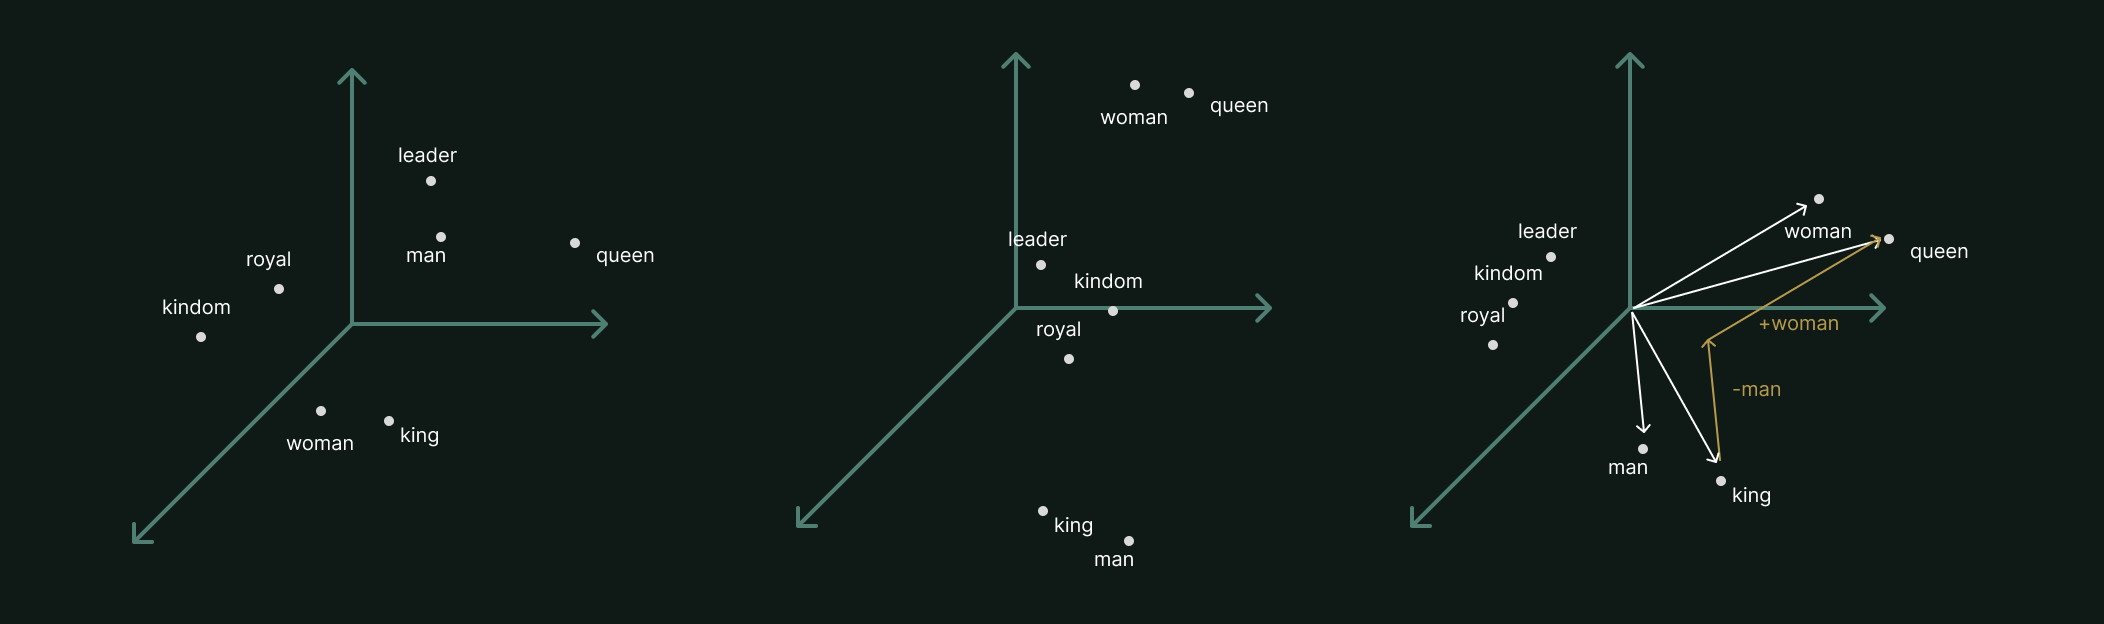

*Izquierda:* vectores al azar. *Centro:* relación débil/no estructurada. *Derecha:* un espacio entrenado donde palabras relacionadas quedan cerca.

Una vez entrenado, el espacio vectorial permite operaciones aritméticas aproximadas del tipo `king - man + woman ≈ queen` (analogías).

## 1. Preprocesamiento de datos

Necesitamos un **corpus** (texto) para entrenar Word2Vec. En este entorno usamos un archivo pequeño para mantener el ejemplo manejable.

En el código de esta sección:

- Leemos el texto desde disco.
- Hacemos una limpieza mínima (minúsculas y separación por espacios).
- Convertimos el corpus en una lista de palabras (`text`), que será la base para construir el vocabulario y los pares (centro, contexto).

In [1]:
with open('docs/txt_emb.txt', 'r') as f:
    text = f.read().replace('\n','')
    print(text[:100], '...')
    text = text.replace('.', ' ').replace(',', ' ').lower().split()
    
text = [w for w in text]
print('Lista del texto:\n',text[:4], '...')

king man ruler royal crown.queen woman ruler royal crown.man male human adult person.woman female hu ...
Lista del texto:
 ['king', 'man', 'ruler', 'royal'] ...


En ML trabajamos con números, así que el texto debe convertirse a **tokens** (aquí: cada palabra es un token).

En el código siguiente hacemos dos cosas clave:

1. **Vocabulario e índices**: creamos un diccionario `word2idx` que asigna a cada palabra un índice entero único, y su inverso `idx2word` para poder interpretar resultados.
2. **Tamaño del vocabulario**: calculamos `vocab_size`, que define el número de embeddings a aprender (una fila por palabra).

In [2]:
word2idx = {word: idx for idx, word in enumerate(list(dict.fromkeys(text)))}
idx2word = {idx: word for word, idx in word2idx.items()}
vocab_size = len(word2idx)
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 105


In [3]:
# Celda de verificación (puedes eliminarla después)
test_words = ['king', 'queen', 'man', 'woman']
for w in test_words:
    if w in word2idx:
        idx = word2idx[w]
        print(f"'{w}' -> idx: {idx} -> back: '{idx2word[idx]}'")
    else:
        print(f"'{w}' NO está en el vocabulario")

'king' -> idx: 0 -> back: 'king'
'queen' -> idx: 5 -> back: 'queen'
'man' -> idx: 1 -> back: 'man'
'woman' -> idx: 6 -> back: 'woman'


## 2. Skip-gram (Word2Vec)

El modelo **Skip-gram** intenta predecir palabras de **contexto** dado un **término objetivo** (palabra central). Por ejemplo, en una ventana alrededor de "gato", el modelo aprende que palabras como "el", "se" o "alfombra" suelen aparecer cerca en el corpus.

Para entrenarlo, construimos ejemplos a partir de una **ventana deslizante**:

- **Pares positivos**: (palabra_centro, palabra_contexto) que sí aparecen dentro de la ventana.
- **Muestras negativas**: (palabra_centro, palabra_aleatoria) que *no* pertenece al contexto. Esto fuerza al modelo a separar asociaciones reales de coincidencias.

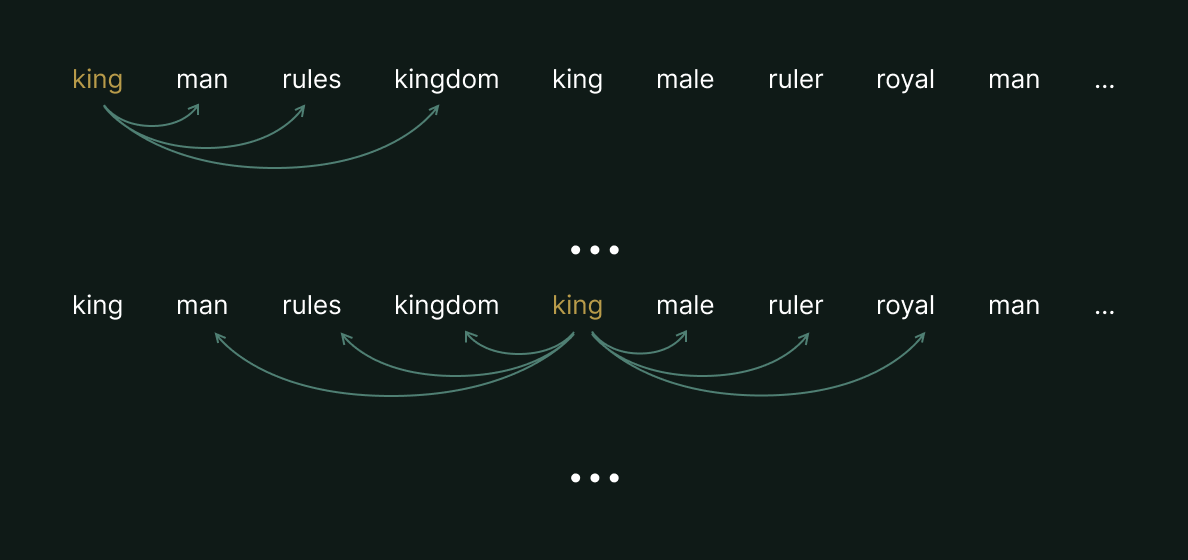

En las siguientes celdas generamos esa lista de ejemplos (con etiquetas 1/0) que luego convertiremos a dataset.

In [4]:
import random

In [5]:
WINDOW_SIZE = 3
NUM_NEGATIVE_SAMPLES = 15

data = []

for idx, center_word in enumerate(text):
    left = max(0, idx - WINDOW_SIZE + 1)
    right = min(len(text), idx+WINDOW_SIZE-1)

    context_words = [word for word in text[left:right] if word != center_word]
    context_set = set(context_words)  # Para verificación O(1)
    for context_word in context_words:
        data.append((center_word, context_word, 1))  # Etiqueta positiva

from collections import defaultdict

dict_data = defaultdict(list)

def add_to_dict(data):
    for center, context, _ in data:
        if context not in dict_data[center]:
            dict_data[center].append(context)

add_to_dict(data)

In [6]:
for idx, center_word in enumerate(set(text)):
    negative_samples = random.sample(
        [w for w in text if w != center_word and w not in dict_data[center_word]],
        NUM_NEGATIVE_SAMPLES
    )
    for negative_word in negative_samples:
        data.append((center_word, negative_word, 0))  # Etiqueta negativa

In [7]:
data[:2]

[('king', 'man', 1), ('man', 'king', 1)]

## 3. Dataset y DataLoader para entrenamiento

A partir de los ejemplos generados, construimos un dataset numérico con la forma:

- `center_word`: índice de la palabra central.
- `context_word`: índice de la palabra de contexto (o negativa).
- `label`: `1` si el par es positivo, `0` si es una muestra negativa.

En esta sección usamos `datasets.Dataset` (Hugging Face) y lo convertimos a formato PyTorch con `.with_format("torch")` para que el `DataLoader` entregue tensores listos para el entrenamiento.

In [8]:
from datasets import Dataset
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim

In [9]:
dataset = Dataset.from_list([
    {
        'center_word': word2idx[c],
        'context_word': word2idx[ctx],
        'label': lbl
    }
    for c, ctx, lbl in data
]).with_format("torch")

train_loader = DataLoader(dataset, shuffle=True)

In [10]:
dataset[:10]

{'center_word': tensor([0, 1, 1, 2, 2, 2, 3, 3, 3, 4]),
 'context_word': tensor([1, 0, 2, 0, 1, 3, 1, 2, 4, 2]),
 'label': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}

## 4. Creación del modelo `Word2Vec`

Implementamos un Word2Vec tipo **Skip-gram** con dos tablas de embeddings:

- `center_embeddings`: representa a la palabra cuando actúa como *centro* (input).
- `context_embeddings`: representa a la palabra cuando actúa como *contexto* (output).

En el `forward`, obtenemos ambos vectores y calculamos su **producto punto**. Ese escalar es un *logit*:

- será alto si el par (centro, contexto) es compatible,
- y bajo si es un par negativo.

Más adelante entrenamos este logit con `BCEWithLogitsLoss`, que combina sigmoide + entropía cruzada binaria de forma numéricamente estable.

In [11]:
class Word2VecModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.center_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.context_embeddings = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, center, context):
        center_embed = self.center_embeddings(center)
        context_embed = self.context_embeddings(context)
        return torch.sum(center_embed * context_embed, dim=1)

    def get_embeddings(self):
        with torch.inference_mode():
            return self.center_embeddings.weight

## 5. Configuración

Definimos los hiperparámetros y objetos de entrenamiento:

- `learning_rate`: tasa de aprendizaje del optimizador.
- `device`: CPU o GPU (si está disponible).
- `criterion`: función de pérdida `BCEWithLogitsLoss` para clasificar pares positivos vs. negativos.

También configuramos el número de épocas y creamos el modelo con una dimensión de embedding (`embedding_dim`). En el notebook probamos distintas dimensiones para visualizar/analizar el espacio aprendido.

In [12]:
learning_rate = 0.01
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.BCEWithLogitsLoss()

In [13]:
num_epochs = 50
model = Word2VecModel(vocab_size, embedding_dim=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

## 6. Funciones de entrenamiento y evaluación

Definimos `train_epoch`, que ejecuta **una época** de entrenamiento sobre el `DataLoader`:

- Pasa los índices (centro/contexto) al `device`.
- Calcula logits con el modelo y evalúa la pérdida con `criterion`.
- Hace `backprop` y actualiza parámetros con el optimizador.
- Calcula métricas simples (accuracy) usando `sigmoid(logits) > 0.5`.

La función retorna la pérdida media por lote y la precisión estimada en esa época.

In [14]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in loader:
        center = batch["center_word"].to(device)
        context = batch["context_word"].to(device)
        labels = batch["label"].float().to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        scores = model(center, context)
        loss = criterion(scores, labels)
        
        # Backward pass
        loss.backward()
        
        optimizer.step()
        
        # Métricas
        total_loss += loss.item()
        predictions = (torch.sigmoid(scores) > 0.5).float()
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(loader), correct / total

## 7. Entrenamiento del modelo

Entrenamos el modelo iterando por `num_epochs` y reportamos la evolución de la pérdida y la precisión. El notebook ejecuta dos entrenamientos con distintas dimensiones de embedding para comparar:

- Un caso de baja dimensión (útil para visualización).
- Un caso de mayor dimensión (más capacidad para capturar relaciones).

En el segundo entrenamiento, si se alcanza `train_acc == 1.0`, se corta temprano para ahorrar cómputo.

In [15]:
# 2 dimensions
print("\nIniciando entrenamiento...")
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")


Iniciando entrenamiento...
Epoch 1/50
  Train Loss: 0.8053, Train Acc: 0.5225
Epoch 10/50
  Train Loss: 0.3816, Train Acc: 0.7930
Epoch 20/50
  Train Loss: 0.3538, Train Acc: 0.8092
Epoch 30/50
  Train Loss: 0.3494, Train Acc: 0.8132
Epoch 40/50
  Train Loss: 0.3380, Train Acc: 0.8150
Epoch 50/50
  Train Loss: 0.3360, Train Acc: 0.8087


In [16]:
num_epochs = 30
model_four_d = Word2VecModel(vocab_size, embedding_dim=5).to(device)
optimizer_five_d = optim.Adam(model_four_d.parameters(), lr=learning_rate)

In [17]:
# 5 dimensions
print("\nIniciando entrenamiento...")
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model_four_d, train_loader, criterion, optimizer_five_d, device)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    if train_acc == 1.0:
        print("Entrenamiento completo con precisión del 100%")
        break


Iniciando entrenamiento...
Epoch 1/30
  Train Loss: 1.0000, Train Acc: 0.5104
Epoch 10/30
  Train Loss: 0.1512, Train Acc: 0.9343
Epoch 20/30
  Train Loss: 0.0763, Train Acc: 0.9676
Epoch 30/30
  Train Loss: 0.0423, Train Acc: 0.9851


In [18]:
import torch.nn.functional as F

In [19]:
class EmbeddingSpace:
    def __init__(self, model, normalize=True):
        self.model = model
        self.normalize = normalize
        self._pairs = None
        self._embeds = None

    def _build_cache(self):
        embeds = self.model.get_embeddings().cpu()
        # Normalizar embeddings (norma L2 = 1) para mejor similitud
        if self.normalize:
            embeds = F.normalize(embeds, p=2, dim=1)
        self._embeds = embeds
        self._pairs = [(idx2word[i], embeds[i].detach()) for i in range(embeds.size(0))]

    @property
    def embeddings_pairs(self):
        if self._pairs is None:
            self._build_cache()
        return self._pairs
    @property
    def embeddings(self):
        if self._embeds is None:
            self._build_cache()
        return self._embeds.detach()

    def get_most_similar(self, word, top_k=5):
        if self._embeds is None:
            self._build_cache()

        word_idx = word2idx[word]
        target = self._embeds[word_idx]

        sims = F.cosine_similarity(self._embeds, target.unsqueeze(0), dim=1)
        top = torch.topk(sims, k=top_k + 1).indices

        result = []
        for idx in top:
            idx = idx.item()
            if idx != word_idx:
                result.append((idx2word[idx], sims[idx].item()))
            if len(result) == top_k:
                break
        return result
    
    def get_vector(self, word):
        """Obtiene el vector (normalizado si normalize=True) de una palabra"""
        if self._embeds is None:
            self._build_cache()
        return self._embeds[word2idx[word]].detach()

In [20]:
embedding_space = EmbeddingSpace(model)

king = embedding_space.get_most_similar('king', top_k=5)
queen = embedding_space.get_most_similar('queen', top_k=5)
man = embedding_space.get_most_similar('man', top_k=5)
woman = embedding_space.get_most_similar('woman', top_k=5)

print("\nPalabras más similares a 'king':", king)
print("\nPalabras más similares a 'queen':", queen)
print("\nPalabras más similares a 'man':", man)
print("\nPalabras más similares a 'woman':", woman)


Palabras más similares a 'king': [('woman', 0.9932392239570618), ('queen', 0.964643120765686), ('royal', 0.9621115326881409), ('man', 0.9472200870513916), ('throne', 0.8572022914886475)]

Palabras más similares a 'queen': [('royal', 0.999955415725708), ('man', 0.9982223510742188), ('woman', 0.9887169599533081), ('king', 0.964643120765686), ('throne', 0.9626222848892212)]

Palabras más similares a 'man': [('royal', 0.9987406134605408), ('queen', 0.9982223510742188), ('woman', 0.9780314564704895), ('throne', 0.9770536422729492), ('ruler', 0.9715245962142944)]

Palabras más similares a 'woman': [('king', 0.9932392239570618), ('queen', 0.9887169599533081), ('royal', 0.9872584342956543), ('man', 0.9780314564704895), ('throne', 0.9111889600753784)]


In [21]:
embedding_space_5d = EmbeddingSpace(model_four_d)

king = embedding_space_5d.get_most_similar('king', top_k=5)
queen = embedding_space_5d.get_most_similar('queen', top_k=5)
man = embedding_space_5d.get_most_similar('man', top_k=5)
woman = embedding_space_5d.get_most_similar('woman', top_k=5)

print("\nPalabras más similares a 'king':", king)
print("\nPalabras más similares a 'queen':", queen)
print("\nPalabras más similares a 'man':", man)
print("\nPalabras más similares a 'woman':", woman)


Palabras más similares a 'king': [('queen', 0.7519768476486206), ('nation', 0.6635375618934631), ('royal', 0.5208331346511841), ('authority', 0.467347651720047), ('state', 0.44054752588272095)]

Palabras más similares a 'queen': [('king', 0.7519768476486206), ('dynasty', 0.6802577972412109), ('loyalty', 0.6252108812332153), ('royal', 0.6009871959686279), ('ceremony', 0.5215564966201782)]

Palabras más similares a 'man': [('crown', 0.7141829133033752), ('person', 0.6522877812385559), ('throne', 0.6150421500205994), ('ruler', 0.5965121388435364), ('leader', 0.5581034421920776)]

Palabras más similares a 'woman': [('male', 0.6609472632408142), ('loyalty', 0.6302618384361267), ('forest', 0.6019831895828247), ('man', 0.5483364462852478), ('lineage', 0.5065388083457947)]


In [22]:
# Usar los vectores del EmbeddingSpace
king_vector = embedding_space.get_vector('king')
queen_vector = embedding_space.get_vector('queen')
man_vector = embedding_space.get_vector('man')
woman_vector = embedding_space.get_vector('woman')

In [23]:
# Usar los vectores del EmbeddingSpace
king_vector_5d = embedding_space_5d.get_vector('king')
queen_vector_5d = embedding_space_5d.get_vector('queen')
man_vector_5d = embedding_space_5d.get_vector('man')
woman_vector_5d = embedding_space_5d.get_vector('woman')

In [24]:
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional

In [25]:
def pca_2d(embeds: torch.Tensor, normalize: bool = True) -> torch.Tensor:
    """
    Aplica PCA y devuelve embeddings en 2D.
    embeds: (N, D)
    """
    # Centrado
    mean = embeds.mean(dim=0)
    X = embeds - mean
    # Covarianza
    cov = X.T @ X / (X.size(0) - 1)
    # Autovalores y autovectores
    eigvals, eigvecs = torch.linalg.eigh(cov)
    # Componentes principales (las de mayor varianza)
    components = eigvecs[:, -2:]
    # Proyección a 2D
    Z = X @ components
    # Normalización L2 (clave para embeddings)
    if normalize:
        Z = F.normalize(Z, dim=1)

    return Z

In [26]:
def plot_embeddings_2d(
    embedding_space: EmbeddingSpace,
    max_words: int = 20,
    compare_words: Optional[Tuple[str, Optional[torch.Tensor], str, Optional[torch.Tensor]]] = None,
    key_words: Optional[List[str]] = None
):
    w_compare, e_compare = [], []
    w_key, e_key = [], []
    w_other, e_other = [], []
    # --- compare words ---
    if compare_words is not None:
        w1, e1, w2, e2 = compare_words
        if e1 is None:
            e1 = embedding_space.get_vector(w1)
        if e2 is None:
            e2 = embedding_space.get_vector(w2)
        w_compare = [w1, w2]
        e_compare = [e1, e2]
    # --- key words ---
    if key_words is not None:
        for w in key_words:
            if w in w_compare:
                continue
            w_key.append(w)
            e_key.append(embedding_space.get_vector(w))
    # --- other words ---
    for w, e in embedding_space.embeddings_pairs[:max_words]:
        if w in w_compare or w in w_key:
            continue
        w_other.append(w)
        e_other.append(e)
    # --- unir ---
    words = w_other + w_compare + w_key
    embeds = torch.stack(e_other + e_compare + e_key)

    dim = embeds.size(1)
    # --- PCA solo si hace falta ---
    if dim == 2:
        X_2d = embeds
    else:
        X_2d = pca_2d(embeds)

    # --- lot ---
    idx_other = len(w_other)
    idx_compare = idx_other + len(w_compare)

    plt.figure(figsize=(10, 8))
    # otras
    if w_other:
        plt.scatter(
            X_2d[:idx_other, 0],
            X_2d[:idx_other, 1],
            c="#9aa0a6",
            alpha=0.5,
            label="otras"
        )
    # compare
    if w_compare:
        x = X_2d[idx_other:idx_compare, 0]
        y = X_2d[idx_other:idx_compare, 1]

        plt.scatter(
            x, y,
            c="#d93025",
            alpha=0.9,
            label="compare"
        )
        # flechas desde el origen
        plt.quiver(
            [0, 0],
            [0, 0],
            x, y,
            angles="xy",
            scale_units="xy",
            scale=1,
            color="#d93025",
            width=0.006
        )
    # key words
    if w_key:
        plt.scatter(
            X_2d[idx_compare:, 0],
            X_2d[idx_compare:, 1],
            c="#1a73e8",
            alpha=0.9,
            label="key_words"
        )
    # etiquetas
    for i, w in enumerate(words):
        plt.text(X_2d[i, 0], X_2d[i, 1], w, fontsize=9)

    plt.title("Word2Vec embeddings (2D)")
    plt.grid(True)
    plt.legend()
    plt.show()

In [27]:
posible_queen = (king_vector - man_vector + woman_vector).detach_().cpu()
posible_queen = F.normalize(posible_queen, p=2, dim=0)
posible_queen

tensor([-0.9574,  0.2888])

In [28]:
queen_vector

tensor([-0.7298,  0.6836])

In [29]:
posible_queen_5d = (king_vector_5d - man_vector_5d + woman_vector_5d).detach_().cpu()
posible_queen_5d = F.normalize(posible_queen_5d, p=2, dim=0)
posible_queen_5d

tensor([-0.2424, -0.6366, -0.4857,  0.3560, -0.4163])

In [30]:
queen_vector_5d

tensor([-0.5254, -0.1747, -0.4782,  0.4193, -0.5376])

In [31]:
# similaridad con woman original
sim = F.cosine_similarity(posible_queen, queen_vector, dim=0)
sim = sim.item()
print(f"\nSimilaridad entre el vector resultante y 'queen': {sim:.4f}")


Similaridad entre el vector resultante y 'queen': 0.8962


In [32]:
# similaridad con woman original
sim_5d = F.cosine_similarity(posible_queen_5d, queen_vector_5d, dim=0)
sim_5d= sim_5d.item()
print(f"\nSimilaridad entre el vector resultante y 'queen': {sim_5d:.4f}")


Similaridad entre el vector resultante y 'queen': 0.8439


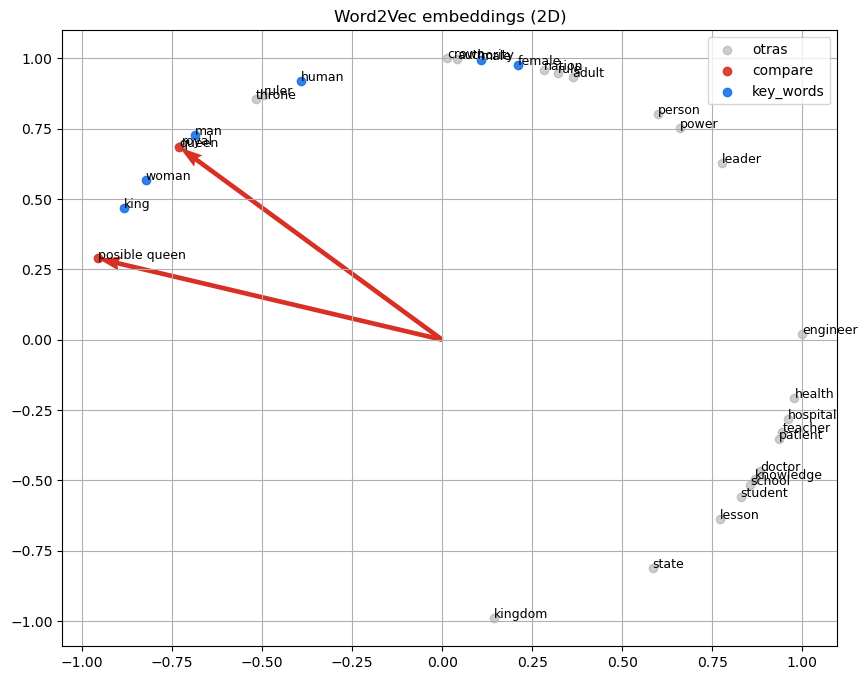

In [33]:
plot_embeddings_2d(embedding_space = embedding_space,
                   max_words=30,
                   compare_words=['posible queen', posible_queen, 'queen', None],
                   key_words=['man', 'woman', 'male', 'female', 'human', 'king']
)

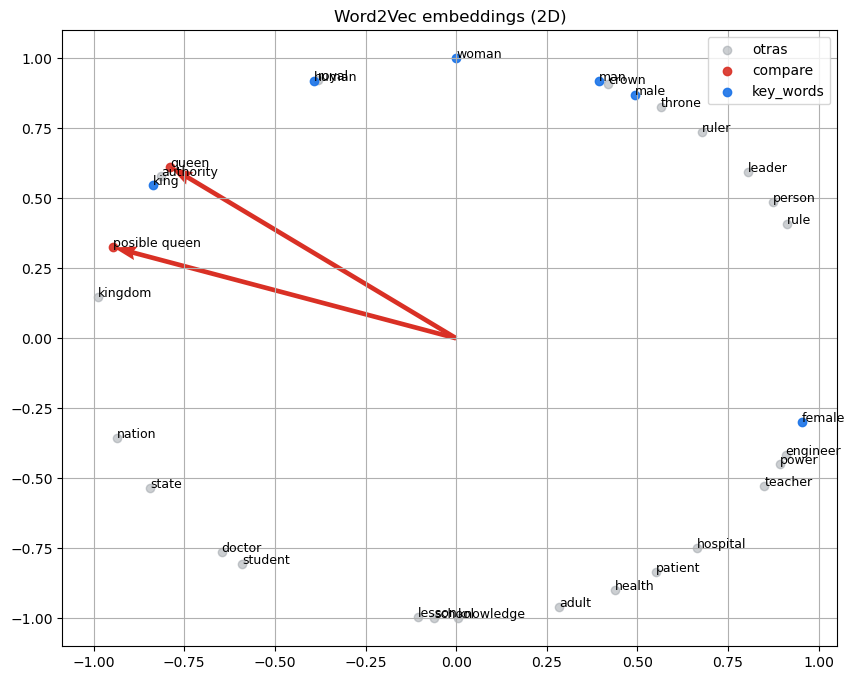

In [34]:
plot_embeddings_2d(embedding_space = embedding_space_5d,
                   max_words=30,
                   compare_words=['posible queen', posible_queen_5d, 'queen', None],
                   key_words=['man', 'woman', 'male', 'female', 'human', 'king']
)